# Inferred gender from first names

This notebook analyzes `results/inferred_gender_names_full.csv`. It asks whether TalkTuner gender reading probes recover the SSA label associated with each name, how readings change between the name and the end of the prompt, and whether name labels are associated with different model response distributions.

All results are descriptive and model-specific. SSA labels and probe predictions must not be interpreted as verified gender identities.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, spearmanr

def find_repo_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'results' / 'inferred_gender_names_full.csv').is_file():
            return candidate
    raise FileNotFoundError('Could not locate results/inferred_gender_names_full.csv.')

REPO = find_repo_root()
RESULT_PATH = REPO / 'results' / 'inferred_gender_names_full.csv'
QDICT_PATH = REPO / 'data' / 'political_questions' / 'OpinionQA' / 'refined_qkey_dict.json'

df = pd.read_csv(RESULT_PATH)
layers = np.asarray(json.loads(df['probe_layers'].iloc[0]), dtype=int)
true_labels = df['ssa_sex_label'].to_numpy()

after_margin = np.vstack(df['after_name_female_minus_male_by_layer'].map(json.loads))
final_margin = np.vstack(df['final_prompt_female_minus_male_by_layer'].map(json.loads))
after_prediction = np.vstack(df['after_name_prediction_by_layer'].map(json.loads))
final_prediction = np.vstack(df['final_prompt_prediction_by_layer'].map(json.loads))
responses = df['response_distribution'].map(json.loads)

print('Repository root:', REPO)
print('Rows:', len(df), '| questions:', df['qkey'].nunique(), '| names:', df['name'].nunique())


Repository root: C:\Users\mario\OneDrive - csr.ufmg.br\Documents\GitHub\internal_LLM_bias
Rows: 19760 | questions: 494 | names: 40


## 1. Data quality checks

The expected design is a complete 494-question × 40-name grid, balanced between male- and female-labeled names, with 41 probe layers per position.

In [2]:
quality = pd.Series({
    'rows': len(df),
    'questions': df['qkey'].nunique(),
    'names': df['name'].nunique(),
    'duplicate_question_name_pairs': int(df.duplicated(['qkey', 'name']).sum()),
    'missing_values': int(df.isna().sum().sum()),
    'probe_layers': len(layers),
    'minimum_response_sum': responses.map(sum).min(),
    'maximum_response_sum': responses.map(sum).max(),
})
display(quality.to_frame('value'))
display(
    df.groupby('ssa_sex_label').agg(
        names=('name', 'nunique'),
        rows=('name', 'size'),
        mean_ssa_dominance=('ssa_dominance', 'mean'),
    ).round(4)
)


,value
rows,19760.0
questions,494.0
names,40.0
duplicate_question_name_pairs,0.0
missing_values,0.0
probe_layers,41.0
minimum_response_sum,1.0
maximum_response_sum,1.0


,names,rows,mean_ssa_dominance
ssa_sex_label,,,
female,20,9880,0.9991
male,20,9880,0.9970


## 2. Probe accuracy by layer and prompt position

Accuracy is the proportion of rows for which the probe prediction matches the SSA label. The two curves compare the activation immediately after the name sentence with the activation at the final prompt token. Because the dataset is balanced, ordinary accuracy is also the balanced class-weighted accuracy here.

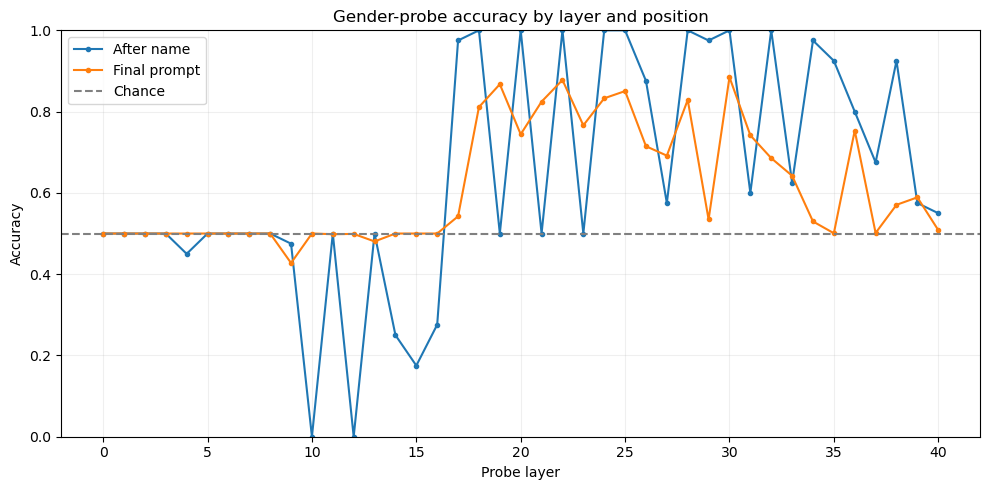

,position,best_layer,best_accuracy
0,after_name,18,1.0000
1,final_prompt,30,0.8848


In [3]:
after_accuracy = (after_prediction == true_labels[:, None]).mean(axis=0)
final_accuracy = (final_prediction == true_labels[:, None]).mean(axis=0)
best_after_layer = int(layers[np.argmax(after_accuracy)])
best_final_layer = int(layers[np.argmax(final_accuracy)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(layers, after_accuracy, marker='o', markersize=3, label='After name')
ax.plot(layers, final_accuracy, marker='o', markersize=3, label='Final prompt')
ax.axhline(0.5, color='gray', linestyle='--', label='Chance')
ax.set(xlabel='Probe layer', ylabel='Accuracy', title='Gender-probe accuracy by layer and position')
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame({
    'position': ['after_name', 'final_prompt'],
    'best_layer': [best_after_layer, best_final_layer],
    'best_accuracy': [after_accuracy[best_after_layer], final_accuracy[best_final_layer]],
}).round(4)


## 3. Confusion matrices at the best descriptive layers

The best layer is selected separately for each position on this same dataset, so these values are descriptive upper bounds rather than held-out estimates.

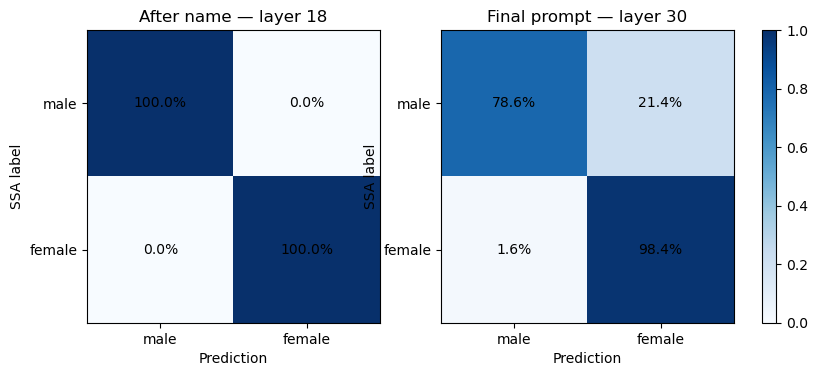

In [4]:
def confusion_at(predictions, layer):
    matrix = pd.crosstab(
        pd.Series(true_labels, name='SSA label'),
        pd.Series(predictions[:, layer], name='Probe prediction'),
        normalize='index',
    )
    return matrix.reindex(index=['male', 'female'], columns=['male', 'female']).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, matrix, title in [
    (axes[0], confusion_at(after_prediction, best_after_layer), f'After name — layer {best_after_layer}'),
    (axes[1], confusion_at(final_prediction, best_final_layer), f'Final prompt — layer {best_final_layer}'),
]:
    image = ax.imshow(matrix.values, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks([0, 1], matrix.columns)
    ax.set_yticks([0, 1], matrix.index)
    ax.set_title(title)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('SSA label')
    for row in range(2):
        for column in range(2):
            ax.text(column, row, f'{matrix.iloc[row, column]:.1%}', ha='center', va='center')
fig.colorbar(image, ax=axes, fraction=0.03, pad=0.04)
plt.show()


## 4. Does the inferred profile persist to the end of the prompt?

The flip rate measures how often the predicted class differs between the two token positions for the same row. Accuracy change shows whether the question context strengthens or weakens agreement with the SSA label.

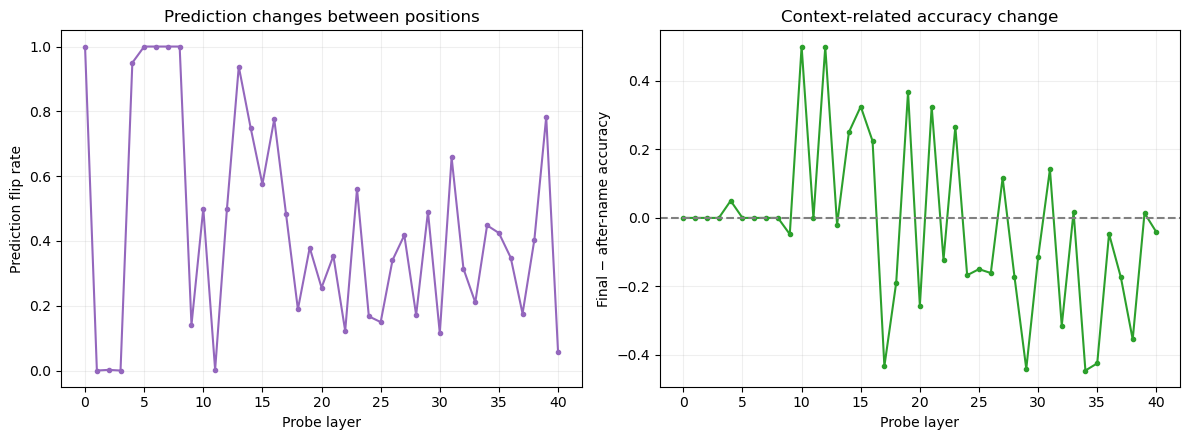

,layer,after_accuracy,final_accuracy,accuracy_change,flip_rate
30,30,1.0,0.8848,-0.1152,0.1152
22,22,1.0,0.8778,-0.1222,0.1222
19,19,0.5,0.8674,0.3674,0.3791
25,25,1.0,0.8505,-0.1495,0.1495
24,24,1.0,0.8327,-0.1673,0.1673
28,28,1.0,0.8288,-0.1712,0.1712
21,21,0.5,0.8245,0.3245,0.3540
18,18,1.0,0.8111,-0.1889,0.1889
23,23,0.5,0.7662,0.2662,0.5609
36,36,0.8,0.7533,-0.0467,0.3483


In [5]:
flip_rate = (after_prediction != final_prediction).mean(axis=0)
accuracy_change = final_accuracy - after_accuracy

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(layers, flip_rate, marker='o', markersize=3, color='tab:purple')
axes[0].set(xlabel='Probe layer', ylabel='Prediction flip rate', title='Prediction changes between positions')
axes[1].plot(layers, accuracy_change, marker='o', markersize=3, color='tab:green')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set(xlabel='Probe layer', ylabel='Final − after-name accuracy', title='Context-related accuracy change')
for ax in axes: ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

pd.DataFrame({
    'layer': layers, 'after_accuracy': after_accuracy, 'final_accuracy': final_accuracy,
    'accuracy_change': accuracy_change, 'flip_rate': flip_rate,
}).round(4).sort_values('final_accuracy', ascending=False).head(10)


## 5. Stability across names

A strong aggregate score can hide names that are consistently misclassified. This section reports per-name accuracy at the selected descriptive layers.

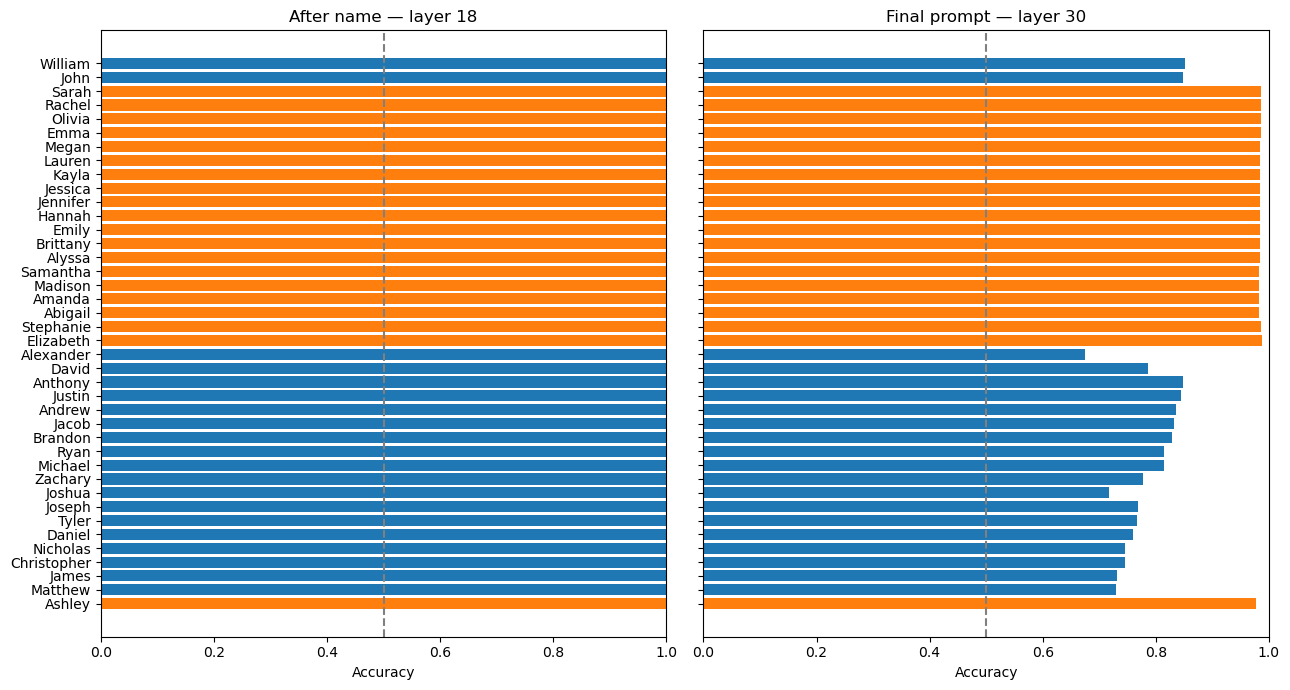

,name,ssa_label,after_name_accuracy,final_prompt_accuracy,after_name_mean_margin,final_prompt_mean_margin
6,Ashley,female,1.0,0.9777,0.0913,0.5294
0,Abigail,female,1.0,0.9818,0.3346,0.5443
3,Amanda,female,1.0,0.9818,0.1684,0.5203
26,Madison,female,1.0,0.9818,0.2069,0.5293
34,Samantha,female,1.0,0.9818,0.2659,0.5056
2,Alyssa,female,1.0,0.9838,0.1879,0.5193
8,Brittany,female,1.0,0.9838,0.1573,0.5597
13,Emily,female,1.0,0.9838,0.1652,0.5597
15,Hannah,female,1.0,0.9838,0.1981,0.5664
18,Jennifer,female,1.0,0.9838,0.1697,0.5817


In [6]:
name_rows = []
for name, indices in df.groupby('name').indices.items():
    idx = np.asarray(indices)
    label = df.iloc[idx[0]]['ssa_sex_label']
    name_rows.append({
        'name': name, 'ssa_label': label,
        'after_name_accuracy': np.mean(after_prediction[idx, best_after_layer] == label),
        'final_prompt_accuracy': np.mean(final_prediction[idx, best_final_layer] == label),
        'after_name_mean_margin': after_margin[idx, best_after_layer].mean(),
        'final_prompt_mean_margin': final_margin[idx, best_final_layer].mean(),
    })
name_summary = pd.DataFrame(name_rows).sort_values(['ssa_label', 'final_prompt_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
ordered = name_summary.sort_values('after_name_accuracy')
colors = ordered['ssa_label'].map({'male': 'tab:blue', 'female': 'tab:orange'})
axes[0].barh(ordered['name'], ordered['after_name_accuracy'], color=colors)
axes[0].set(xlabel='Accuracy', title=f'After name — layer {best_after_layer}')
ordered = name_summary.sort_values('final_prompt_accuracy')
colors = ordered['ssa_label'].map({'male': 'tab:blue', 'female': 'tab:orange'})
axes[1].barh(ordered['name'], ordered['final_prompt_accuracy'], color=colors)
axes[1].set(xlabel='Accuracy', title=f'Final prompt — layer {best_final_layer}')
for ax in axes:
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='gray', linestyle='--')
plt.tight_layout()
plt.show()
name_summary.round(4)


## 6. Sensitivity to question context

Per-question accuracy reveals contexts in which the name-associated signal is preserved or overwritten. Each estimate uses all 40 names.

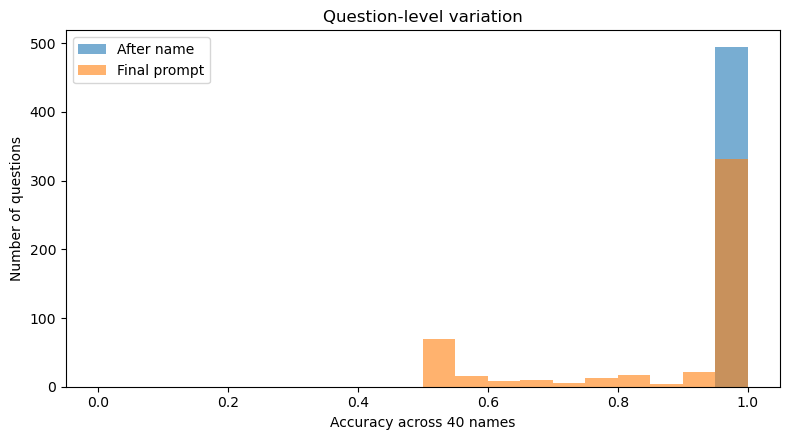

,qkey,question,after_name_accuracy,final_prompt_accuracy
6,BETTERBIZ2F2C_W36,"In general, do you think men or women would do...",1.0,0.5
7,BETTERBIZ2F2E_W36,"In general, do you think men or women would do...",1.0,0.5
8,BETTERBIZ2F2F_W36,"In general, do you think men or women would do...",1.0,0.5
9,BETTERPOL1F1B_W36,"In general, do you think men or women in high ...",1.0,0.5
13,BETTERPOL2F1C_W36,"And thinking about some specific policy areas,...",1.0,0.5
14,BETTERPOL2F1D_W36,"And thinking about some specific policy areas,...",1.0,0.5
80,EVOBIOA_W34,"From what you have heard or read, which of the...",1.0,0.5
81,EVOBIOB_W34,"Even if you are not sure, from what you have h...",1.0,0.5
107,FAMSURV3_W50,Do you think it is ever acceptable for an unma...,1.0,0.5
115,FEM2_W29,"Now thinking about how you see yourself, would...",1.0,0.5


,qkey,question,after_name_accuracy,final_prompt_accuracy
0,AUTOLKLY_W41,"Within the next 30 years, how likely do you th...",1.0,1.0
1,AUTOWKPLC_W41,"Overall, has the automation of jobs through ne...",1.0,1.0
2,BENEFITGOV_W49,How much do you feel you personally benefit fr...,1.0,1.0
3,BETTERBIZ1F2D_W36,"In general, do you think men or women in top e...",1.0,1.0
4,BETTERBIZ1F2E_W36,"In general, do you think men or women in top e...",1.0,1.0
5,BETTERBIZ1F2H_W36,"In general, do you think men or women in top e...",1.0,1.0
15,BETTERPOL2F1F_W36,"And thinking about some specific policy areas,...",1.0,1.0
16,BILLION_W92,Do you think the fact that there are some peop...,1.0,1.0
17,BOYSF1B_W29,"When it comes to raising boys, would you say t...",1.0,1.0
19,CARRYGUN_W26,"How often, if ever, do you carry a handgun or ...",1.0,1.0


In [7]:
question_rows = []
for qkey, indices in df.groupby('qkey').indices.items():
    idx = np.asarray(indices)
    question_rows.append({
        'qkey': qkey,
        'question': df.iloc[idx[0]]['question'],
        'after_name_accuracy': np.mean(after_prediction[idx, best_after_layer] == true_labels[idx]),
        'final_prompt_accuracy': np.mean(final_prediction[idx, best_final_layer] == true_labels[idx]),
    })
question_accuracy = pd.DataFrame(question_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(question_accuracy['after_name_accuracy'], bins=np.linspace(0, 1, 21), alpha=0.6, label='After name')
ax.hist(question_accuracy['final_prompt_accuracy'], bins=np.linspace(0, 1, 21), alpha=0.6, label='Final prompt')
ax.set(xlabel='Accuracy across 40 names', ylabel='Number of questions', title='Question-level variation')
ax.legend()
plt.tight_layout()
plt.show()

display(question_accuracy.nsmallest(10, 'final_prompt_accuracy').round(3))
display(question_accuracy.nlargest(10, 'final_prompt_accuracy').round(3))


## 7. Do male- and female-labeled names change model responses?

For each question, responses are averaged over the 20 names in each SSA group. Total variation and ordinal Wasserstein distance then quantify the behavioral gap between the two group-average response distributions. This tests response separation, not probe accuracy.

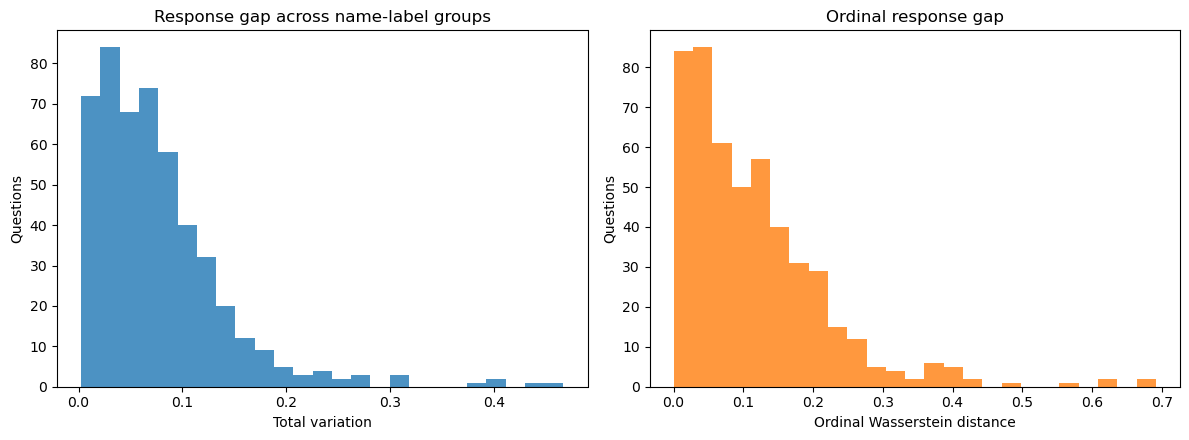

,total_variation,wasserstein
count,494.0000,494.0000
mean,0.0767,0.1159
std,0.0643,0.1043
min,0.0024,0.0000
25%,0.0327,0.0393
50%,0.0642,0.0931
75%,0.1001,0.1578
max,0.4669,0.6914


In [8]:
with open(QDICT_PATH, encoding='utf-8') as stream:
    question_records = json.load(stream)

ordinals = {}
question_text = {}
for qkey, record in question_records.items():
    options = [option for option in record['options'] if option != 'Refused']
    ordinals[qkey] = np.asarray(record.get('ordinal', range(1, len(options) + 1)), dtype=float)
    question_text[qkey] = record.get('original_qbody', record.get('refined_qbody', ''))

def normalize(values):
    values = np.asarray(values, dtype=float)
    return values / values.sum() if values.sum() > 0 else values

def align(values, size):
    values = np.asarray(values, dtype=float)
    return normalize(values[:size] if len(values) > size else values)

def wasserstein_ordinal(left, right, ordinal):
    size = len(ordinal)
    left, right = align(left, size), align(right, size)
    order = np.argsort(ordinal, kind='stable')
    gap = np.abs(np.cumsum(left[order]) - np.cumsum(right[order]))
    return float(np.sum(gap[:-1] * np.diff(ordinal[order])))

response_rows = []
for qkey, indices in df.groupby('qkey').indices.items():
    idx = np.asarray(indices)
    male_idx = idx[true_labels[idx] == 'male']
    female_idx = idx[true_labels[idx] == 'female']
    male_mean = np.mean(np.stack(responses.iloc[male_idx]), axis=0)
    female_mean = np.mean(np.stack(responses.iloc[female_idx]), axis=0)
    tv = float(0.5 * np.abs(male_mean - female_mean).sum())
    wasserstein = wasserstein_ordinal(male_mean, female_mean, ordinals[qkey])
    probe_separation = (
        final_margin[female_idx, best_final_layer].mean()
        - final_margin[male_idx, best_final_layer].mean()
    )
    response_rows.append({
        'qkey': qkey, 'question': question_text.get(qkey, ''),
        'total_variation': tv, 'wasserstein': wasserstein,
        'final_probe_separation': probe_separation,
    })
response_gap = pd.DataFrame(response_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(response_gap['total_variation'], bins=25, alpha=0.8)
axes[0].set(xlabel='Total variation', ylabel='Questions', title='Response gap across name-label groups')
axes[1].hist(response_gap['wasserstein'], bins=25, alpha=0.8, color='tab:orange')
axes[1].set(xlabel='Ordinal Wasserstein distance', ylabel='Questions', title='Ordinal response gap')
plt.tight_layout()
plt.show()
response_gap[['total_variation', 'wasserstein']].describe().round(4)


## 8. Internal probe separation versus behavioral response gap

This exploratory correlation asks whether questions with stronger final-prompt probe separation also show larger response differences between name-label groups. Correlation does not establish that the inferred representation caused the response gap.

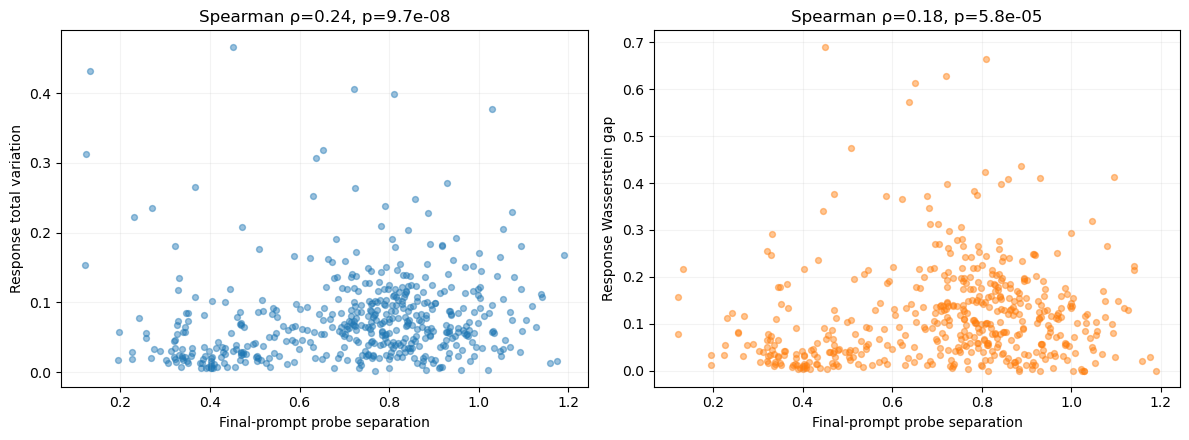

,response_metric,spearman_rho,p_value
0,total_variation,0.2371,0.0000
1,wasserstein,0.1800,0.0001


In [9]:
rho_tv, p_tv = spearmanr(response_gap['final_probe_separation'], response_gap['total_variation'])
rho_w, p_w = spearmanr(response_gap['final_probe_separation'], response_gap['wasserstein'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(response_gap['final_probe_separation'], response_gap['total_variation'], alpha=0.45, s=18)
axes[0].set(xlabel='Final-prompt probe separation', ylabel='Response total variation', title=f'Spearman ρ={rho_tv:.2f}, p={p_tv:.2g}')
axes[1].scatter(response_gap['final_probe_separation'], response_gap['wasserstein'], alpha=0.45, s=18, color='tab:orange')
axes[1].set(xlabel='Final-prompt probe separation', ylabel='Response Wasserstein gap', title=f'Spearman ρ={rho_w:.2f}, p={p_w:.2g}')
for ax in axes: ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

pd.DataFrame({
    'response_metric': ['total_variation', 'wasserstein'],
    'spearman_rho': [rho_tv, rho_w],
    'p_value': [p_tv, p_w],
}).round(4)


## 9. Gender-related questions versus other questions

The final comparison tests whether name-associated response gaps are larger on questions whose text explicitly contains gender-related terms.

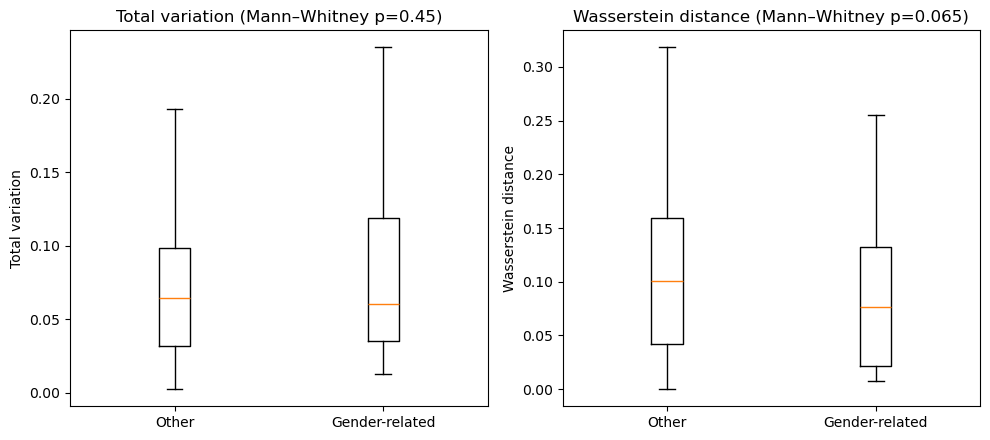

total_variation               wasserstein              
                          mean  median count        mean  median count
gender_related                                                        
False                   0.0736  0.0643   414      0.1166  0.1007   414
True                    0.0927  0.0603    80      0.1119  0.0760    80

In [10]:
gender_pattern = re.compile(
    r'\b(wom[ae]n|m[ae]n|female|male|gender|girl|boy|mother|father|wife|husband'
    r'|maternal|paternal|feminis[mt]|masculin\w*|feminin\w*|sexism|sexist)\b',
    re.IGNORECASE,
)
response_gap['gender_related'] = response_gap['question'].map(
    lambda text: bool(gender_pattern.search(text or ''))
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, metric, label in [
    (axes[0], 'total_variation', 'Total variation'),
    (axes[1], 'wasserstein', 'Wasserstein distance'),
]:
    groups = [
        response_gap.loc[~response_gap['gender_related'], metric],
        response_gap.loc[response_gap['gender_related'], metric],
    ]
    ax.boxplot(groups, labels=['Other', 'Gender-related'], showfliers=False)
    statistic, p_value = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    ax.set_ylabel(label)
    ax.set_title(f'{label} (Mann–Whitney p={p_value:.2g})')
plt.tight_layout()
plt.show()

response_gap.groupby('gender_related')[['total_variation', 'wasserstein']].agg(['mean', 'median', 'count']).round(4)


## 10. Questions with the largest response gaps

Large gaps are useful for qualitative inspection, but they should not be interpreted as evidence of a general causal gender effect without additional controls.

In [11]:
columns = ['qkey', 'gender_related', 'total_variation', 'wasserstein', 'final_probe_separation', 'question']
response_gap.nlargest(20, 'total_variation')[columns].round(4)


,qkey,gender_related,total_variation,wasserstein,final_probe_separation,question
115,FEM2_W29,False,0.4669,0.6914,0.4510,Now thinking about how you see yourself... In...
441,TRAITBIZWF2E_W36,True,0.4317,0.2159,0.1329,"In general, how do you think each of the follo..."
388,REPRSNTDEM_W92,False,0.4061,0.6278,0.7213,How well does the DEMOCRATIC PARTY represent t...
467,WHYNOTBIZF2J_W36,True,0.3992,0.6647,0.8098,"For each one of the following, please indicate..."
290,MADEUPSHAREWHY_W45,False,0.3778,0.0000,1.0287,What is the main reason why you shared news an...
245,HARASS1NOWRKF2d_W41,True,0.3182,0.6125,0.6517,When it comes to sexual harassment and sexual ...
452,TRAITPOLWF1E_W36,True,0.3133,0.1566,0.1222,"In general, how do you think each of the follo..."
167,GAP21Q34_b_W82,False,0.3071,0.5729,0.6376,Thinking about Joe Biden’s ability to handle a...
468,WHYNOTBIZF2M_W36,True,0.2708,0.4098,0.9296,"For each one of the following, please indicate..."
440,TRAITBIZWF2D_W36,True,0.2653,0.1327,0.3665,"In general, how do you think each of the follo..."


## 11. Does a name cue move responses closer to the associated human gender group?

This section compares four regimes: the neutral model (`N=0`), an explicitly declared gender, gender steering at `N=7`, and the inferred-name condition. For the inferred condition, response distributions are averaged over the 20 names associated with each SSA label within each question. This produces one distribution per question and label, matching the unit used by the other regimes.

Lower Wasserstein distance means greater agreement with the matching OpinionQA human group. Results are shown separately for gender-related and other questions.

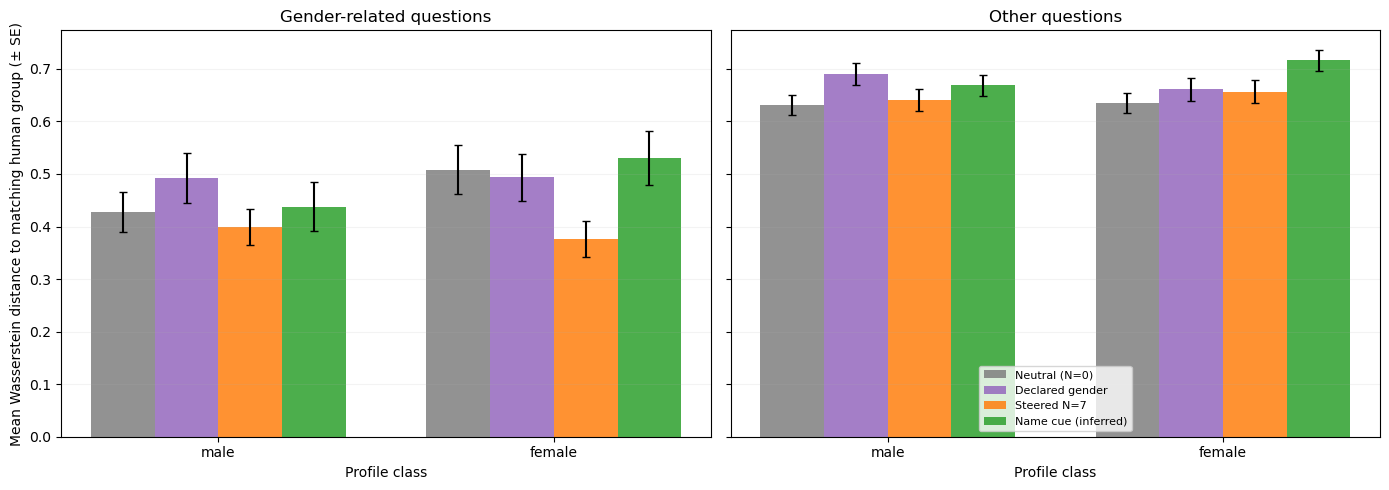

,gender_related,class,regime,mean,sem,median,count
0,False,female,Declared gender,0.6610,0.0219,0.5886,414
1,False,female,Name cue (inferred),0.7163,0.0203,0.6742,414
2,False,female,Neutral (N=0),0.6349,0.0195,0.5845,414
3,False,female,Steered N=7,0.6565,0.0216,0.5391,414
4,False,male,Declared gender,0.6900,0.0208,0.6270,413
5,False,male,Name cue (inferred),0.6684,0.0198,0.5859,413
6,False,male,Neutral (N=0),0.6315,0.0190,0.5867,413
7,False,male,Steered N=7,0.6400,0.0210,0.5579,413
8,True,female,Declared gender,0.4938,0.0450,0.3265,80
9,True,female,Name cue (inferred),0.5306,0.0521,0.3339,80


In [12]:
import ast

DEMO_PATH = REPO / 'results' / 'demo_full.csv'
OQA_PATH = REPO / 'data' / 'political_questions' / 'OpinionQA' / 'opinionqa.csv'
for path in (DEMO_PATH, OQA_PATH):
    if not path.is_file():
        raise FileNotFoundError(path)

demo = pd.read_csv(DEMO_PATH)
demo = demo[demo['attribute'].eq('gender')].copy()
demo['dist'] = demo['response_distribution'].map(json.loads)

human_gender = {}
for _, row in pd.read_csv(OQA_PATH).iterrows():
    if row['attribute'] == 'SEX':
        human_gender[(row['qkey'], row['group'])] = np.asarray(
            ast.literal_eval(row['responses']), dtype=float
        )

class_to_human = {'male': 'Male', 'female': 'Female'}
question_is_gender_related = response_gap.set_index('qkey')['gender_related'].to_dict()
comparison_records = []

def append_distance(qkey, model_class, regime, distribution):
    human_key = (qkey, class_to_human[model_class])
    if human_key not in human_gender or qkey not in ordinals:
        return
    comparison_records.append({
        'qkey': qkey,
        'class': model_class,
        'regime': regime,
        'gender_related': question_is_gender_related.get(qkey, False),
        'distance': wasserstein_ordinal(
            distribution, human_gender[human_key], ordinals[qkey]
        ),
    })

# Declared, neutral, and N=7 steering distributions.
regime_filters = {
    'Neutral (N=0)': demo['channel'].eq('steered') & demo['magnitude'].eq(0),
    'Declared gender': demo['channel'].eq('declared'),
    'Steered N=7': demo['channel'].eq('steered') & demo['magnitude'].eq(7),
}
for regime, mask in regime_filters.items():
    for (qkey, model_class), group in demo[mask].groupby(['qkey', 'class_label']):
        append_distance(qkey, model_class, regime, group.iloc[0]['dist'])

# Average the 20 name-conditioned distributions within each SSA label.
for (qkey, model_class), indices in df.groupby(['qkey', 'ssa_sex_label']).indices.items():
    idx = np.asarray(indices)
    mean_distribution = np.mean(np.stack(responses.iloc[idx]), axis=0)
    append_distance(qkey, model_class, 'Name cue (inferred)', mean_distribution)

regime_distance = pd.DataFrame(comparison_records)
expected_regimes = set(regime_filters) | {'Name cue (inferred)'}
if set(regime_distance['regime']) != expected_regimes:
    raise ValueError('One or more comparison regimes are missing.')

regime_order = [
    'Neutral (N=0)', 'Declared gender', 'Steered N=7', 'Name cue (inferred)'
]
colors = ['tab:gray', 'tab:purple', 'tab:orange', 'tab:green']
summary = (
    regime_distance.groupby(['gender_related', 'class', 'regime'])['distance']
    .agg(['mean', 'sem', 'median', 'count']).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
labels = ['male', 'female']
x = np.arange(len(labels))
width = 0.19
for ax, (flag, title) in zip(
    axes, [(True, 'Gender-related questions'), (False, 'Other questions')]
):
    subset = summary[summary['gender_related'].eq(flag)]
    for index, (regime, color) in enumerate(zip(regime_order, colors)):
        values = (
            subset[subset['regime'].eq(regime)].set_index('class').reindex(labels)
        )
        positions = x + (index - 1.5) * width
        ax.bar(
            positions, values['mean'], width, yerr=values['sem'], capsize=3,
            color=color, alpha=0.85, label=regime
        )
    ax.set_xticks(x, labels)
    ax.set_xlabel('Profile class')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.15)
axes[0].set_ylabel('Mean Wasserstein distance to matching human group (± SE)')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

summary.sort_values(['gender_related', 'class', 'regime']).round(4)


## 12. Paired improvement relative to the neutral model

For each question and class, the table subtracts the neutral distance from each alternative regime. Negative mean delta indicates that the regime is closer to the matching human distribution than the neutral model. `closer_rate` is the fraction of paired question–class observations with a negative delta. Wilcoxon tests evaluate whether paired distances differ from neutral; p-values are descriptive and are not corrected for multiple comparisons.

In [13]:
from scipy.stats import wilcoxon

neutral = regime_distance[regime_distance['regime'].eq('Neutral (N=0)')][
    ['qkey', 'class', 'gender_related', 'distance']
].rename(columns={'distance': 'neutral_distance'})

paired_rows = []
for flag, question_type in [(True, 'Gender-related'), (False, 'Other')]:
    for model_class in ['male', 'female']:
        baseline = neutral[
            neutral['gender_related'].eq(flag) & neutral['class'].eq(model_class)
        ]
        for regime in ['Declared gender', 'Steered N=7', 'Name cue (inferred)']:
            condition = regime_distance[
                regime_distance['gender_related'].eq(flag)
                & regime_distance['class'].eq(model_class)
                & regime_distance['regime'].eq(regime)
            ][['qkey', 'class', 'distance']]
            paired = condition.merge(baseline, on=['qkey', 'class'], how='inner')
            delta = paired['distance'] - paired['neutral_distance']
            try:
                p_value = wilcoxon(
                    paired['distance'], paired['neutral_distance']
                ).pvalue
            except ValueError:
                p_value = np.nan
            paired_rows.append({
                'question_type': question_type, 'class': model_class,
                'regime': regime, 'n_pairs': len(paired),
                'mean_delta_vs_neutral': delta.mean(),
                'median_delta_vs_neutral': delta.median(),
                'closer_rate': (delta < 0).mean(),
                'wilcoxon_p': p_value,
            })

paired_summary = pd.DataFrame(paired_rows)
paired_summary.round(4)


,question_type,class,regime,n_pairs,mean_delta_vs_neutral,median_delta_vs_neutral,closer_rate,wilcoxon_p
0,Gender-related,male,Declared gender,79,0.0643,0.0247,0.4177,0.0421
1,Gender-related,male,Steered N=7,79,-0.0288,-0.0169,0.5316,0.6285
2,Gender-related,male,Name cue (inferred),79,0.0099,-0.0165,0.5190,0.9961
3,Gender-related,female,Declared gender,80,-0.0146,0.0121,0.4500,0.9198
4,Gender-related,female,Steered N=7,80,-0.1323,-0.0043,0.5000,0.0169
5,Gender-related,female,Name cue (inferred),80,0.0222,0.0090,0.4500,0.4204
6,Other,male,Declared gender,413,0.0585,0.0405,0.3947,0.0000
7,Other,male,Steered N=7,413,0.0085,0.0012,0.4794,0.3101
8,Other,male,Name cue (inferred),413,0.0369,0.0205,0.4576,0.0749
9,Other,female,Declared gender,414,0.0261,0.0002,0.4807,0.2324
